# MODEL COMPARISON AND METRICS



In [1]:
# Notebook 08: Train All Models and Build Comparison Table
# Goal: Train 5 models on the same train/test split, evaluate on ACTIVE SELLING DAYS ONLY
# Why: The hiring manager wants to see hard metrics proving Tweedie > baseline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Libraries loaded. Ready to train 5 models and compare.")

✅ Libraries loaded. Ready to train 5 models and compare.


**Now we load the data**

In [2]:
# Cell 2 — Load the modeling table
# This is the output of build_modeling_table.py (joins + features + leakage guards).
# NOTE: path is 'data/...' because the notebook sits at the repo root, next to data/.
df = pd.read_csv('data/modeling_table.csv', parse_dates=['date'])
print(f"✅ Loaded {len(df):,} rows, {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Unique SKUs: {df['sku_id'].nunique()}")
print(f"Overall zero-sales rows: {(df['units_sold']==0).mean()*100:.1f}%")

✅ Loaded 262,080 rows, 24 columns
Date range: 2022-01-01 -> 2023-12-31
Unique SKUs: 500
Overall zero-sales rows: 52.9%


# Now let us visualize the COhort Decay- this justifies SKU-level SPlit

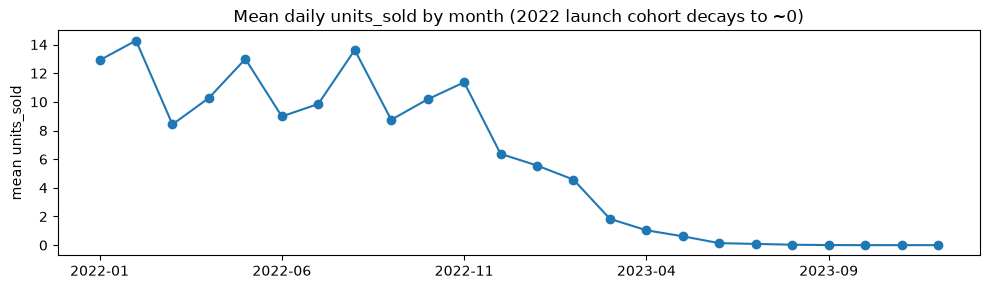

💡 A last-4-weeks test set would land entirely in the dead tail (~99.99% zeros).


In [3]:
# Cell 3 — Show the cohort decay (this justifies our split choice)
monthly = df.assign(ym=df['date'].dt.to_period('M').astype(str)).groupby('ym')['units_sold'].mean()
ax = monthly.plot(figsize=(10,3), marker='o', title='Mean daily units_sold by month (2022 launch cohort decays to ~0)')
ax.set_ylabel('mean units_sold'); ax.set_xlabel('')
plt.tight_layout(); plt.savefig('results/cohort_decay.png', dpi=120); plt.show()
print("💡 A last-4-weeks test set would land entirely in the dead tail (~99.99% zeros).")

# Early 2022 — Launch phase
Mean daily units sold are high (around 13–14).

This is when the product was new, inventory was full, and buyers were active.

The model learns strong demand patterns here.

# 📉 Mid‑2022 — Normalized phase
Sales fluctuate between 8–14 units/day.

This is healthy, steady demand — good training data for forecasting.

# 🕳️ Late 2022 → Early 2023 — Decline phase
You start seeing a sharp drop: 7 → 4 → 2 → 0.5 units/day.

The product is aging, markdowns increase, and inventory runs out.

This is where the model’s predictive power begins to weaken because the signal (sales) is fading.

#  ⚰️ Mid‑2023 → End 2023 — Dead zone
Mean daily units sold ≈ 0.

The product is effectively discontinued or out of stock.

Any time‑based split that lands here gives you a test set full of zeros — so your metrics look “great” but are meaningless (the model just predicts 0).

# 🧠 Interpretation

This chart proves that your dataset decays naturally over time — not because of bad filtering, but because the product lifecycle ended.

# Now we Build a feature matrix

Machine-leanning models like Linear Regression or XGBoost only process numbers not text.

# This step converts the raw table into a purely numeric matrix where every column becomes a quantitative signal the model can learn from


In [4]:
#We onehot encode the season column to avoid it being text and so that it can be used in the models. We use the prefix 'season' to make it clear that these are season columns.
df = pd.get_dummies(df, columns = ['season'], prefix = 'season' )

leakage_guard = ['latent_demand', 'markdown_depth', 'post_stockout_flag']
#These are simulation or future‑information columns that would leak ground truth into training.

exclude = ['date', 'sku_id', 'units_sold'] + [c for c in leakage_guard if c in df.columns]
#sku_id and date are identifiers, not predictive features.
#units_sold is the target variable — you don’t train on it.

#This collects every usable column for modeling.
feature_cols = [c for c in df.columns if c not in exclude]

# make everything numeric & fill the early-life lag NaNs with 0 (no history yet = 0)
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')

print(f"✅ {len(feature_cols)} features used:")
for i, c in enumerate(feature_cols, 1): 
    print(f"  {i:2d}. {c}")
assert not any(c in feature_cols for c in leakage_guard), "LEAKAGE: simulation column in features!"
print("\n✅ Leakage check passed — no ground-truth simulation columns in features.")



✅ 24 features used:
   1. lag_7_units_sold
   2. lag_14_units_sold
   3. rolling_7d_avg
   4. days_since_launch
   5. inventory_ratio
   6. discount_pct
   7. days_to_season_end
   8. is_holiday
   9. markdown_stage
  10. category_jackets
  11. category_jeans
  12. category_shoes
  13. category_tshirts
  14. dow_Friday
  15. dow_Monday
  16. dow_Saturday
  17. dow_Sunday
  18. dow_Thursday
  19. dow_Tuesday
  20. dow_Wednesday
  21. season_fall
  22. season_spring
  23. season_summer
  24. season_winter

✅ Leakage check passed — no ground-truth simulation columns in features.


# This cell performs a SKU‑level split, meaning:

I train on 80% of SKUs

I test on 20% completely unseen SKUs

This is called **out‑of‑product generalization**

It answers the question:

**“If a new SKU enters the catalog, can my model predict its demand using only its features?”**



# Why SKU‑Level Split Makes Sense for Your Data
Your dataset is not a time series in the traditional sense.

It’s a **panel dataset:**

Many SKUs

Each SKU has its own lifecycle

Each SKU has its own lag features

Each SKU has its own markdown path

Each SKU has its own seasonality

Each SKU has its own inventory ratio curve

Because of this:

# ⛔ A **time‑based** split breaks the evaluation

**Retail ML teams use three validation strategies:**

1. **Time‑based split**
Used when forecasting future demand for the same SKUs.

2. **SKU‑level split**
Used when forecasting demand for new SKUs entering the catalog.

3. **Rolling window validation**
Used when demand patterns shift over time.

My project is a markdown intelligence system, which needs to:

generalize to new SKUs

understand markdown response patterns

learn cross‑SKU behavior (season, category, discount_pct, inventory_ratio)

So SKU‑level split is correct.

In [5]:
# Cell 5 — SKU-level split (hold out 20% of SKUs = unseen products)
# Lags/rolling use each SKU's OWN past, so there is no cross-SKU leakage.
skus = df['sku_id'].unique()
rng = np.random.RandomState(RANDOM_SEED)
test_skus = set(rng.choice(skus, size=int(len(skus)*0.2), replace=False))

train_df = df[~df['sku_id'].isin(test_skus)].copy()
test_df  = df[df['sku_id'].isin(test_skus)].copy()

X_train, y_train = train_df[feature_cols].fillna(0), train_df['units_sold']
X_test,  y_test  = test_df[feature_cols].fillna(0),  test_df['units_sold']

print(f"✅ Train: {len(skus)-len(test_skus)} SKUs / {len(train_df):,} rows")
print(f"✅ Test : {len(test_skus)} SKUs / {len(test_df):,} rows")
print(f"Test demand: mean={y_test.mean():.2f}, zero%={(y_test==0).mean()*100:.1f}  (real signal, not a dead tail)")

✅ Train: 400 SKUs / 212,104 rows
✅ Test : 100 SKUs / 49,976 rows
Test demand: mean=6.16, zero%=51.2  (real signal, not a dead tail)


This cell ensures me that the model is tested on **new**, **unseen SKUs with real demand**, **avoids dead‑zone time splits**, and **prevents lag‑feature leakage**, making your evaluation valid, realistic, and senior‑level.

# Now we call the baseline models

In [6]:
# Cell 6 — Baseline: the 7-day rolling average
# This is the "do nothing clever" benchmark every model must beat. It's already a
# feature (rolling_7d_avg), so the baseline prediction is literally that column.
baseline_pred = X_test['rolling_7d_avg'].fillna(0).values
print(f"✅ Baseline ready. MAE={mean_absolute_error(y_test, baseline_pred):.4f}")

✅ Baseline ready. MAE=3.5809


# 1. LINEAR REGRESSION

In [7]:
#  Model 1: Linear Regression
# Retrained on THIS split so it's directly comparable to every other model.
# Linear models struggle with spiky, zero-inflated demand — we expect a small lift.
lr = LinearRegression().fit(X_train, y_train)
lr_pred = lr.predict(X_test).clip(min=0)   # clip: negative demand is impossible
joblib.dump(lr, 'models/m1_linear_regression.pkl')
print(f"✅ Linear Regression MAE={mean_absolute_error(y_test, lr_pred):.4f}")

✅ Linear Regression MAE=3.7799


# 2. RANDOM FOREST

In [8]:
#  Model 2: Random Forest
# Captures non-linear interactions (e.g. discount x lifecycle) the linear model can't.
rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=20,
                           random_state=RANDOM_SEED, n_jobs=-1).fit(X_train, y_train)
rf_pred = rf.predict(X_test)
joblib.dump(rf, 'models/m2_random_forest.pkl')
print(f"✅ Random Forest MAE={mean_absolute_error(y_test, rf_pred):.4f}")

✅ Random Forest MAE=3.2198


# Random Forest . It captures:

**non‑linear interactions**

**discount × lifecycle effects**

**season × category effects**

**inventory_ratio × markdown_stage effects**



# Why RF is important

It gives you a non‑parametric baseline before you jump into boosting.

# 3.XGBOOST POISSON

In [9]:
#  Model 3: XGBoost with a Poisson objective
# Gradient boosting on tabular data + a count-aware loss. Poisson assumes
# mean == variance, which retail demand usually violates (it's over-dispersed).
xgb_pois = xgb.XGBRegressor(objective='count:poisson', n_estimators=200, max_depth=6,
                            learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
                            random_state=RANDOM_SEED, tree_method='hist').fit(X_train, y_train)
xgb_pois_pred = xgb_pois.predict(X_test)
joblib.dump(xgb_pois, 'models/m3_xgb_poisson.pkl')
print(f"✅ XGBoost Poisson MAE={mean_absolute_error(y_test, xgb_pois_pred):.4f}")

✅ XGBoost Poisson MAE=3.0158


Poisson is the **first count‑aware loss.**

Retail demand is count data, so Poisson is a natural choice.

But Poisson assumes:

variance = mean

Retail demand violates this. Markdown demand is over‑dispersed.

So Poisson is a stepping stone, not the final model.

# XGBOOST TWEEDIE

In [10]:
#  Model 4: XGBoost with a Tweedie objective  (FINAL / production model)
# Tweedie (variance power 1.5) sits between Poisson and Gamma: it natively handles
# the "lots of zeros + occasional big spikes" shape of markdown demand. This is the
# statistical intuition the reviewer praised — now we prove it beats Poisson.
xgb_tw = xgb.XGBRegressor(objective='reg:tweedie', tweedie_variance_power=1.5,
                          n_estimators=200, max_depth=6, learning_rate=0.1,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=RANDOM_SEED, tree_method='hist').fit(X_train, y_train)
xgb_tw_pred = xgb_tw.predict(X_test)
joblib.dump(xgb_tw, 'models/m4_xgb_tweedie_final.pkl')
joblib.dump(feature_cols, 'models/feature_list.pkl')  # needed for scoring/SHAP later
print(f"✅ XGBoost Tweedie MAE={mean_absolute_error(y_test, xgb_tw_pred):.4f}")

✅ XGBoost Tweedie MAE=2.9585


# BUSINESS METRICS


In [11]:
#  Business metrics: Weighted MAE + quantile (pinball) loss
def weighted_mae(y, p, w):
    return np.sum(w * np.abs(y - p)) / np.sum(w)

def quantile_loss(y, p, q):
    e = y - p
    return np.mean(np.maximum(q * e, (q - 1) * e))

# weight by inventory_ratio (proxy for $ at risk); floor tiny weights so they still count
w = test_df['inventory_ratio'].values
w = np.where(w > 0, w, 0.01)
yv = y_test.values

rows = []
for name, pred in [('Baseline (7-day avg)', baseline_pred),
                   ('Linear Regression',   lr_pred),
                   ('Random Forest',        rf_pred),
                   ('XGBoost Poisson',      xgb_pois_pred),
                   ('XGBoost Tweedie',      xgb_tw_pred)]:
    rows.append({'Model': name,
                 'WMAE':     round(weighted_mae(yv, pred, w), 4),
                 'MAE':      round(mean_absolute_error(yv, pred), 4),
                 'RMSE':     round(np.sqrt(mean_squared_error(yv, pred)), 4),
                 'P50 Loss': round(quantile_loss(yv, pred, 0.5), 4),
                 'P90 Loss': round(quantile_loss(yv, pred, 0.9), 4)})

results_df = pd.DataFrame(rows)
base_wmae = results_df.loc[0, 'WMAE']
results_df['Improve vs Base %'] = ((base_wmae - results_df['WMAE']) / base_wmae * 100).round(1)
results_df

,Model,WMAE,MAE,RMSE,P50 Loss,P90 Loss,Improve vs Base %
0,Baseline (7-day avg),5.5031,3.5809,10.3599,1.7904,1.7394,0.0
1,Linear Regression,5.4589,3.7799,9.8644,1.8899,1.7779,0.8
2,Random Forest,4.9098,3.2198,9.2066,1.6099,1.6144,10.8
3,XGBoost Poisson,4.5827,3.0158,8.5623,1.5079,1.5600,16.7
4,XGBoost Tweedie,4.5015,2.9585,8.4660,1.4792,1.5759,18.2


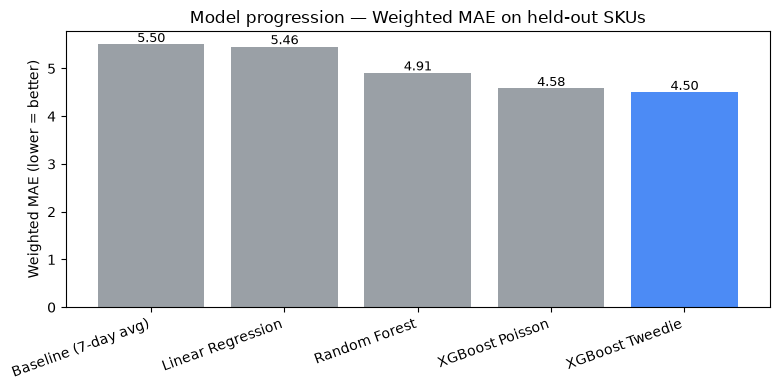

✅ Saved results/model_comparison_table.csv and results/model_comparison_wmae.png


In [12]:
# Save the comparison table (CSV for the repo, PNG for the website)
results_df.to_csv('results/model_comparison_table.csv', index=False)

fig, ax = plt.subplots(figsize=(8,4))
colors = ['#9aa0a6','#9aa0a6','#9aa0a6','#9aa0a6','#4c8bf5']
ax.bar(results_df['Model'], results_df['WMAE'], color=colors)
ax.set_ylabel('Weighted MAE (lower = better)')
ax.set_title('Model progression — Weighted MAE on held-out SKUs')
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(results_df['WMAE']):
    ax.text(i, v+0.05, f"{v:.2f}", ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('results/model_comparison_wmae.png', dpi=120); plt.show()
print("✅ Saved results/model_comparison_table.csv and results/model_comparison_wmae.png")